In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
import plotly.graph_objects as go

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving laptop2.csv to laptop2 (1).csv


In [ ]:
df = pd.read_csv("/content/laptop2.csv")

EDA

In [ ]:
df.shape

(1303, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int64  
 3   OpSys          1237 non-null   object 
 4   Weight         1303 non-null   float64
 5   Touchscreen    1303 non-null   int64  
 6   CpuCompany     1303 non-null   object 
 7   ClockSpeed     1303 non-null   float64
 8   Flash Storage  1176 non-null   float64
 9   HDD            1201 non-null   float64
 10  Hybrid         1177 non-null   float64
 11  SSD            1303 non-null   float64
 12  GPU            1303 non-null   object 
 13  Ppi            1303 non-null   float64
 14  Price          1303 non-null   float64
dtypes: float64(8), int64(2), object(5)
memory usage: 152.8+ KB


In [ ]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,CpuCompany,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,GPU,Ppi,Price
0,Apple,Ultrabook,8,macOS,1.37,0,Intel,2.3,0.000,0.0,0.0,0.128,Intel,312.781955,71378.6832
1,Apple,Ultrabook,8,macOS,1.34,0,Intel,1.8,0.128,0.0,0.0,0.000,Intel,175.939850,47895.5232
2,HP,Notebook,8,NaN,1.86,0,Intel,2.5,0.000,0.0,0.0,0.256,Intel,192.307692,30636.0000
3,Apple,Ultrabook,16,macOS,1.83,0,Intel,2.7,NaN,0.0,0.0,0.512,AMD,303.896104,135195.3360
4,Apple,Ultrabook,8,macOS,1.37,0,Intel,3.1,0.000,0.0,0.0,0.256,Intel,312.781955,96095.8080


Identifying Numerical and Categorical Columns

In [ ]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns:  {numerical_columns}")
print(f"Categorical columns:  {categorical_columns}")

Numerical columns:  ['Ram', 'Weight', 'Touchscreen', 'ClockSpeed', 'Flash Storage', 'HDD', 'Hybrid', 'SSD', 'Ppi', 'Price']
Categorical columns:  ['Company', 'TypeName', 'OpSys', 'CpuCompany', 'GPU']


In [ ]:
for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print('-----')

Company
['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']
-----
TypeName
['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']
-----
OpSys
['macOS' nan 'Windows' 'Mac' 'Linux' 'Android' 'Chrome']
-----
CpuCompany
['Intel' 'AMD' 'Samsung']
-----
GPU
['Intel' 'AMD' 'Nvidia' 'ARM']
-----


In [ ]:
df.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,66
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,127
HDD,102


In [ ]:
df.duplicated().sum()

np.int64(21)

Distribution of price

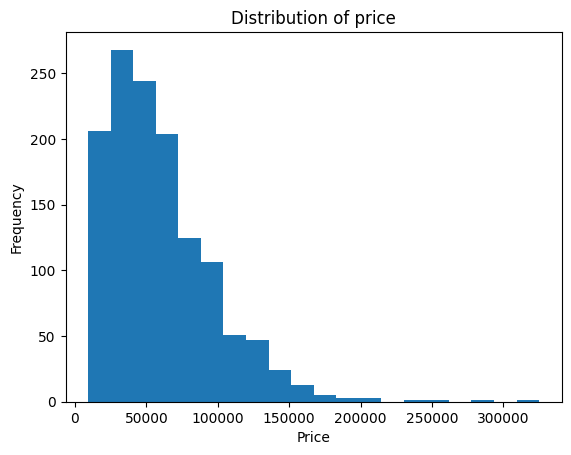

In [ ]:
plt.hist(df['Price'], bins=20)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of price")
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

corr_matrix = df.corr(numeric_only=True)


fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
            aspect="auto"
)

fig.update_layout(
    title="Correlation Heatmap",
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

calculating the correlation between numerical features and the target variable (Price).

In [ ]:
corr_matrix = df[numerical_columns].corr()

corr_matrix['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
SSD,0.670799
Ppi,0.472762
ClockSpeed,0.430293
Weight,0.210370
Touchscreen,0.191226
Hybrid,0.019489
Flash Storage,-0.031031
HDD,-0.106697


Detecte outliers

 Outlier Detection Summary
Ram: Found 221 outliers (Lower_bound : -2.00, Upper_bound: 14.00)
Weight: Found 46 outliers (Lower_bound : 0.30, Upper_bound: 3.50)
Touchscreen: Found 192 outliers (Lower_bound : 0.00, Upper_bound: 0.00)
ClockSpeed: Found 4 outliers (Lower_bound : 0.95, Upper_bound: 3.75)
Flash Storage: Found 66 outliers (Lower_bound : 0.00, Upper_bound: 0.00)
HDD: Found 0 outliers (Lower_bound : -1.50, Upper_bound: 2.50)
Hybrid: Found 10 outliers (Lower_bound : 0.00, Upper_bound: 0.00)
SSD: Found 18 outliers (Lower_bound : -0.38, Upper_bound: 0.64)
Ppi: Found 124 outliers (Lower_bound : 112.10, Upper_bound: 275.60)
Price: Found 29 outliers (Lower_bound : -39124.57, Upper_bound: 150313.54)


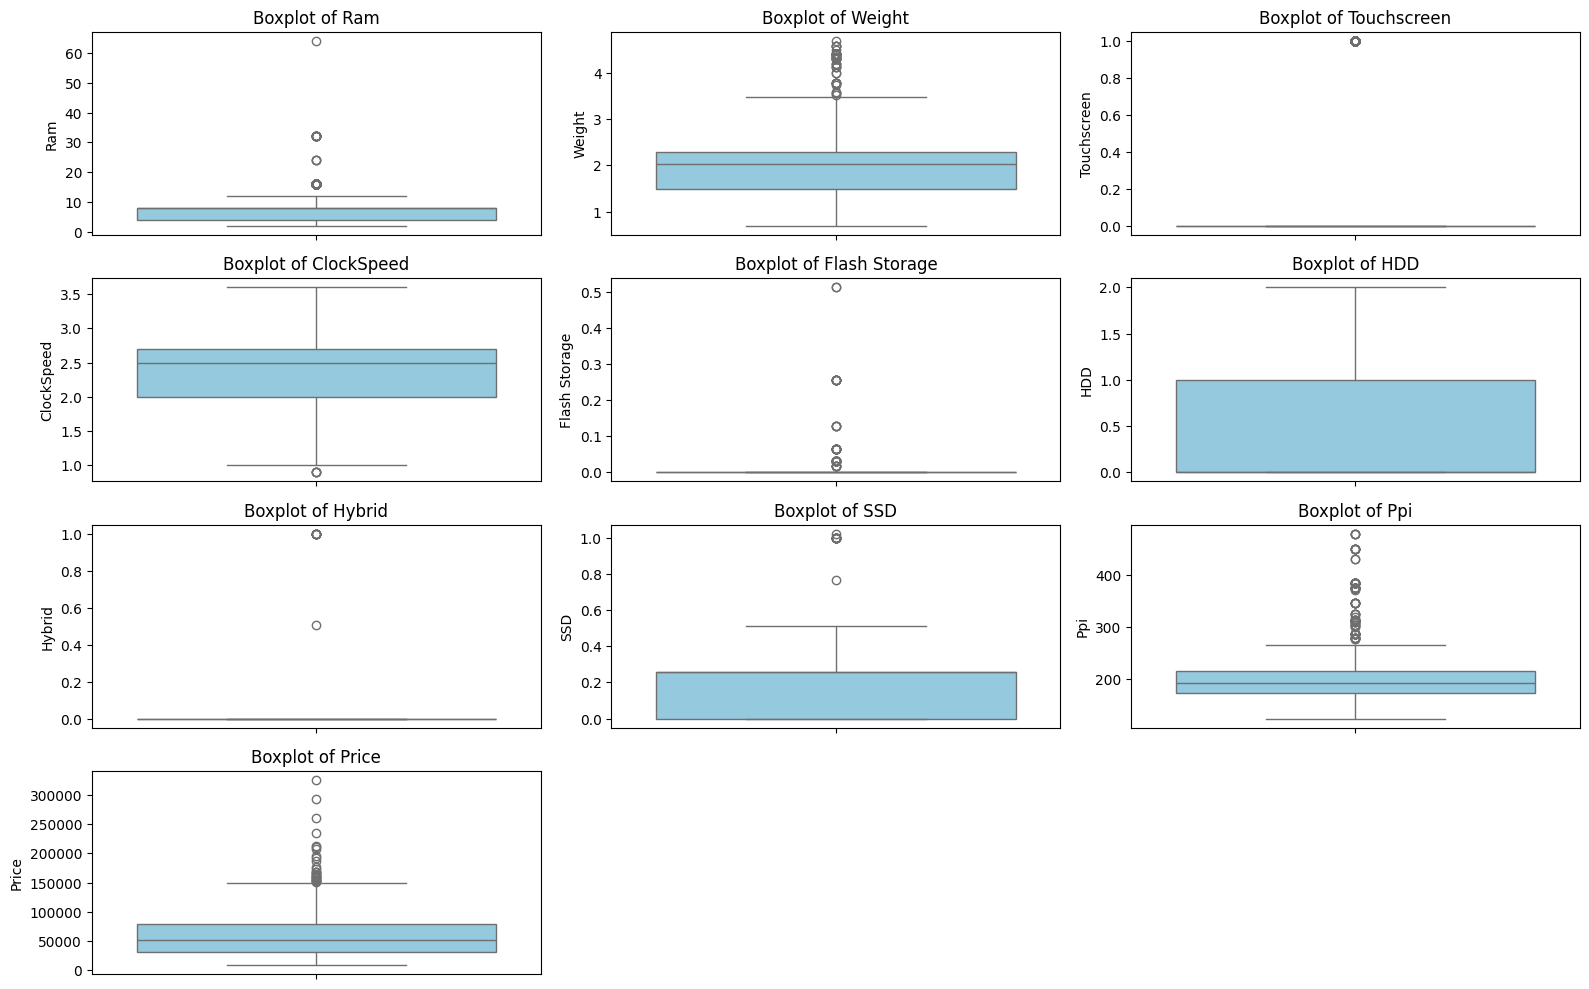

In [ ]:
print(" Outlier Detection Summary")
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: Found {len(outliers)} outliers (Lower_bound : {lower_bound :.2f}, Upper_bound: {upper_bound:.2f})")

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
def interactive_scatter_with_regression(df, x_col, y_col, title="Scatter Plot with Regression Line"):
    x = df[x_col].values.astype(float)
    y = df[y_col].values.astype(float)
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
    if denominator == 0:
        slope = 0
    else:
        slope = numerator / denominator
    intercept = y_mean - slope * x_mean
    x_line = np.array([x.min(), x.max()])
    y_line = intercept + slope * x_line
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x,y=y,mode='markers',name='Data Points',marker=dict(size=8, color='skyblue', opacity=0.7)))
    fig.add_trace(go.Scatter(x=x_line,y=y_line,mode='lines',name='Regression Line',line=dict(color='red', width=2, dash='dash'),visible=True))
    equation_text = f"y = {intercept:.4f} + {slope:.4f}·x"
    fig.update_layout(title=title,xaxis_title=x_col,yaxis_title=y_col,template='plotly_white',hovermode='closest',annotations=[dict(x=0.05,y=0.95,xref='paper',yref='paper', text=equation_text,showarrow=False,font=dict(size=12, color='red'),bgcolor='rgba(255,255,255,0.8)')])
    return fig

In [ ]:
#show relation between price & Ram
fig1 = interactive_scatter_with_regression(df, x_col='Ram', y_col='Price',title="Relationship: RAM vs Price")
fig1.show()
#show relation between SSD & price
fig2 = interactive_scatter_with_regression(df, x_col='SSD', y_col='Price',title="Relationship: SSD vs Price")
fig2.show()
#show relation between Ppi  price
fig3 = interactive_scatter_with_regression(df, x_col='Ppi', y_col='Price',title="Relationship: PPI vs Price")
fig3.show()

***Preprocessing***

drop duplicates

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

Train test split

We split the data first to avoid data leakage, so that any preprocessing (like scaling or encoding) is learned only from the training set and then applied to the test set.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

handle outliers

we handle outliers to reduce their effect on the model and improve performance.

In [ ]:
import numpy as np

for col in ['Ram', 'Weight', 'Ppi']:
    upper_limit = X_train[col].quantile(0.90)

    X_train[col] = X_train[col].clip(upper=upper_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit)

lower_limit_clock = X_train['ClockSpeed'].quantile(0.10)
X_train['ClockSpeed'] = X_train['ClockSpeed'].clip(lower=lower_limit_clock)
X_test['ClockSpeed'] = X_test['ClockSpeed'].clip(lower=lower_limit_clock)




Log transformation


This step is used to reduce skewness in the data and make the distribution more normal.

In [ ]:

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)


missing values

In [ ]:
X_train.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,58
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,97
HDD,86


In [ ]:
X_test.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,8
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,30
HDD,16


Missing values are filled using:
- Mean for numerical columns  
- Mode for categorical columns  

The values are computed from the training set and then applied to both training and test sets .

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns
for col in cat_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mode()[0])
    X_test[col] = X_test[col].fillna(X_train[col].mode()[0])

In [ ]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mean())
    X_test[col] = X_test[col].fillna(X_train[col].mean())

In [ ]:
X_train.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,0
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,0
HDD,0


In [ ]:
X_test.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,0
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,0
HDD,0


One-Hot Encoding

Categorical columns are converted into binary columns to make them suitable for machine learning models.

This prevents the model from assuming any order between categories.

In [ ]:

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1025, 47)
X_test shape: (257, 47)


Standard Scalar

This step scales numerical features to have a mean of 0 and a standard deviation of 1.

In [ ]:
train_mean = X_train[num_cols].mean()
train_std = X_train[num_cols].std()
train_std[train_std == 0] = 1

X_train[num_cols] = (X_train[num_cols] - train_mean) / train_std
X_test[num_cols] = (X_test[num_cols] - train_mean) / train_std

X_train_final = X_train
X_test_final = X_test

print(f"Final Train shape: {X_train_final.shape}")

Final Train shape: (1025, 47)


# Choosing the features

In [ ]:
X_test_final.columns
X_train_final.columns

Index(['Ram', 'Weight', 'Touchscreen', 'ClockSpeed', 'Flash Storage', 'HDD',
       'Hybrid', 'SSD', 'Ppi', 'Company_Acer', 'Company_Apple', 'Company_Asus',
       'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google',
       'Company_HP', 'Company_Huawei', 'Company_LG', 'Company_Lenovo',
       'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'OpSys_Android', 'OpSys_Chrome', 'OpSys_Linux', 'OpSys_Mac',
       'OpSys_Windows', 'OpSys_macOS', 'CpuCompany_AMD', 'CpuCompany_Intel',
       'CpuCompany_Samsung', 'GPU_AMD', 'GPU_ARM', 'GPU_Intel', 'GPU_Nvidia'],
      dtype='object')

In [ ]:
features = ['Ram','SSD','Ppi','Company_Apple','Company_HP','TypeName_Gaming','GPU_Nvidia','CpuCompany_Intel']
X_test_final = X_test_final[features].values
X_train_final = X_train_final[features].values


#Building the Model:

** Simple Linear Regression Statistical View **

 **Role :** The LinearRegressionStatisticalView class fits a simple linear regression model and computes all key statistical values from scratch using numpy and scipy.
It tests whether the slope (β₁) is zero (no relationship) or not.

In [ ]:
class LinearRegressionStatisticalView:
    def __init__(self, alpha: float = 0.05):
        self.alpha = alpha
        self._fitted = False

    def fit(self, X, Y):
        self.X = np.array(X, dtype=float)
        self.Y = np.array(Y, dtype=float)
        self.n = len(self.X)

        x_mean = np.mean(self.X)
        y_mean = np.mean(self.Y)

        SXX = np.sum((self.X - x_mean) ** 2)
        SXY = np.sum((self.X - x_mean) * (self.Y - y_mean))

        self.beta_1 = SXY / SXX
        self.beta_0 = y_mean - self.beta_1 * x_mean

        y_pred = self.beta_0 + self.beta_1 * self.X
        SSE = np.sum((self.Y - y_pred) ** 2)
        SSR = np.sum((y_pred - y_mean) ** 2)
        SST = np.sum((self.Y - y_mean) ** 2)

        self.df_model = 1
        self.df_resid = self.n - 2
        self.df_total = self.n - 1

        self.MSR = SSR / self.df_model
        self.MSE = SSE / self.df_resid
        self.SSE = SSE
        self.SSR = SSR
        self.SST = SST

        self.se = np.sqrt(self.MSE)
        self.se_beta_1 = self.se / np.sqrt(SXX)
        self.se_beta_0 = self.se * np.sqrt(np.sum(self.X**2) / (self.n * SXX))

        self._fitted = True
        return self

    def f_statistic(self) -> float:
        return float(self.MSR / self.MSE)

    def f_critical(self) -> float:
        return float(stats.f.ppf(1 - self.alpha, self.df_model, self.df_resid))

    def beta_confidence_intervals(self) -> dict:
        t_crit = stats.t.ppf(1 - self.alpha / 2, self.df_resid)
        return {
            "beta_0": (self.beta_0 - t_crit * self.se_beta_0,
                       self.beta_0 + t_crit * self.se_beta_0),
            "beta_1": (self.beta_1 - t_crit * self.se_beta_1,
                       self.beta_1 + t_crit * self.se_beta_1)
        }

    def degrees_of_freedom(self) -> dict:
        return {
            "df_model": self.df_model,
            "df_resid": self.df_resid,
            "df_total": self.df_total
        }

    def r_squared(self) -> float:
        return float(self.SSR / self.SST)

    def r(self) -> float:
        r_val = np.sqrt(self.r_squared())
        return float(r_val if self.beta_1 >= 0 else -r_val)

    def summary(self) -> dict:
        return {
            "f_critical": self.f_critical(),
            "f_stat": self.f_statistic(),
            "beta_confidence_intervals": self.beta_confidence_intervals(),
            "degrees_of_freedom": self.degrees_of_freedom(),
            "r_squareddef": self.r_squared(),
            "r": self.r()
        }


def compare(df, x_col_1: str, x_col_2: str, y_col: str, alpha: float = 0.05) -> dict:
    model_a = LinearRegressionStatisticalView(alpha=alpha)
    model_b = LinearRegressionStatisticalView(alpha=alpha)

    model_a.fit(df[x_col_1].values, df[y_col].values)
    model_b.fit(df[x_col_2].values, df[y_col].values)

    f1 = model_a.f_statistic()
    f2 = model_b.f_statistic()

    return {
        "predictor_1": x_col_1,
        "predictor_2": x_col_2,
        "f_stat_1": f1,
        "f_stat_2": f2,
        "best_predictor": x_col_1 if f1 >= f2 else x_col_2
    }

In [ ]:
model = LinearRegressionStatisticalView(alpha=0.05)
model.fit(df['Ram'].values, df['Price'].values)

print("Summary:")
print(model.summary())

Summary:
{'f_critical': 3.8487339667929445, 'f_stat': 1554.307650759568, 'beta_confidence_intervals': {'beta_0': (np.float64(11946.42960598742), np.float64(17262.65658173762)), 'beta_1': (np.float64(5155.943667510429), np.float64(5695.946245809623))}, 'degrees_of_freedom': {'df_model': 1, 'df_resid': 1280, 'df_total': 1281}, 'r_squareddef': 0.5483905920879931, 'r': 0.7405339911766327}


In [ ]:
result = compare(df, x_col_1='Ram', x_col_2='SSD', y_col='Price')
print(result)

print(f"\nBest predictor: {result['best_predictor']}")
print(f"Because its F-statistic ({max(result['f_stat_1'], result['f_stat_2']):.2f}) is higher,")
print("meaning it explains more of the variation in Price.")

{'predictor_1': 'Ram', 'predictor_2': 'SSD', 'f_stat_1': 1554.307650759568, 'f_stat_2': 1038.4013599400375, 'best_predictor': 'Ram'}

Best predictor: Ram
Because its F-statistic (1554.31) is higher,
meaning it explains more of the variation in Price.


Now i use the compare() function to find out which predictor (Ram or SSD) has a stronger linear relationship with Price.

The one with the higher F-statistic is the better predictor.

In [ ]:
model = LinearRegressionStatisticalView(alpha=0.05)
model.fit(X_train_final[:, 0], y_train)
print(model.summary())

{'f_critical': 3.850564853073997, 'f_stat': 1158.1106828047207, 'beta_confidence_intervals': {'beta_0': (np.float64(10.775298064673724), np.float64(10.828212524280758)), 'beta_1': (np.float64(0.43258952102045045), np.float64(0.48552981146114893))}, 'degrees_of_freedom': {'df_model': 1, 'df_resid': 1023, 'df_total': 1024}, 'r_squareddef': 0.5309729084062303, 'r': 0.7286788787979451}
